In [110]:
# https://platform.olimpiada-ai.ro/en/problems/204

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [111]:
data = pd.read_csv("/kaggle/input/datasets/abukanabek/the-puzzle-guild-archives/data.csv")
data.shape

(4000, 17)

In [112]:
data.head()

,RoundID,skill_level,teamwork_score,puzzle_intuition,arcane_knowledge,focus_level,strategy_depth,location,puzzle_type,secret_mechanism,story_arc,tech_assist,night_mode,mystery_power,team_synergy,focus_magic,style
0,0,61.174814,58.879307,1.604486,-3.356868,54.648389,51.830036,Crystal Cave,Logic,Ancient Map,Forbidden Magic,1,1,36.831020,51.201478,34.967259,-1
1,1,58.133589,58.039304,1.588768,-3.556428,53.020806,45.971086,Rooftop Garden,Maze,Magic Key,Lost Civilization,0,1,33.492061,53.257079,35.649418,-1
2,2,59.697344,57.087653,1.226585,7.152169,53.011371,48.309135,Rooftop Garden,Sequence,Magic Key,Cursed Treasure,1,1,38.773553,50.167258,32.095970,-1
3,3,59.996048,57.537453,1.685187,9.359777,50.653686,46.579880,Crystal Cave,Maze,Ancient Map,Lost Civilization,1,1,39.509380,50.588093,32.026528,-1
4,4,60.066185,58.342768,1.068056,-4.594134,54.653283,50.473253,Mystic Bridge,Sequence,Teleport Rune,Forbidden Magic,0,1,33.643430,53.205376,33.049910,-1


In [113]:
orig_data = data.copy()
data = pd.get_dummies(data)
for c in data.select_dtypes('bool').columns:
    data[c] = data[c].astype(int)
data.head()

,RoundID,skill_level,teamwork_score,puzzle_intuition,arcane_knowledge,focus_level,strategy_depth,tech_assist,night_mode,mystery_power,...,secret_mechanism_Ancient Map,secret_mechanism_Hidden Door,secret_mechanism_Magic Key,secret_mechanism_Oracle Vision,secret_mechanism_Secret Code,secret_mechanism_Teleport Rune,story_arc_Ancient Prophecy,story_arc_Cursed Treasure,story_arc_Forbidden Magic,story_arc_Lost Civilization
0,0,61.174814,58.879307,1.604486,-3.356868,54.648389,51.830036,1,1,36.831020,...,1,0,0,0,0,0,0,0,1,0
1,1,58.133589,58.039304,1.588768,-3.556428,53.020806,45.971086,0,1,33.492061,...,0,0,1,0,0,0,0,0,0,1
2,2,59.697344,57.087653,1.226585,7.152169,53.011371,48.309135,1,1,38.773553,...,0,0,1,0,0,0,0,1,0,0
3,3,59.996048,57.537453,1.685187,9.359777,50.653686,46.579880,1,1,39.509380,...,1,0,0,0,0,0,0,0,0,1
4,4,60.066185,58.342768,1.068056,-4.594134,54.653283,50.473253,0,1,33.643430,...,0,0,0,0,0,1,0,0,1,0


In [114]:
data['style'].value_counts()

style
-1    3640
 0     120
 1     120
 2     120
Name: count, dtype: int64

In [115]:
from sklearn.decomposition import PCA

numeric_features = [c for c in data.select_dtypes('number').columns if c not in ['RoundID', 'style']]

pca = PCA(n_components=2)

data_pca = pca.fit_transform(data[numeric_features])

data_pca.shape, pca.explained_variance_ratio_.sum().item()

((4000, 2), 0.9232707394982123)

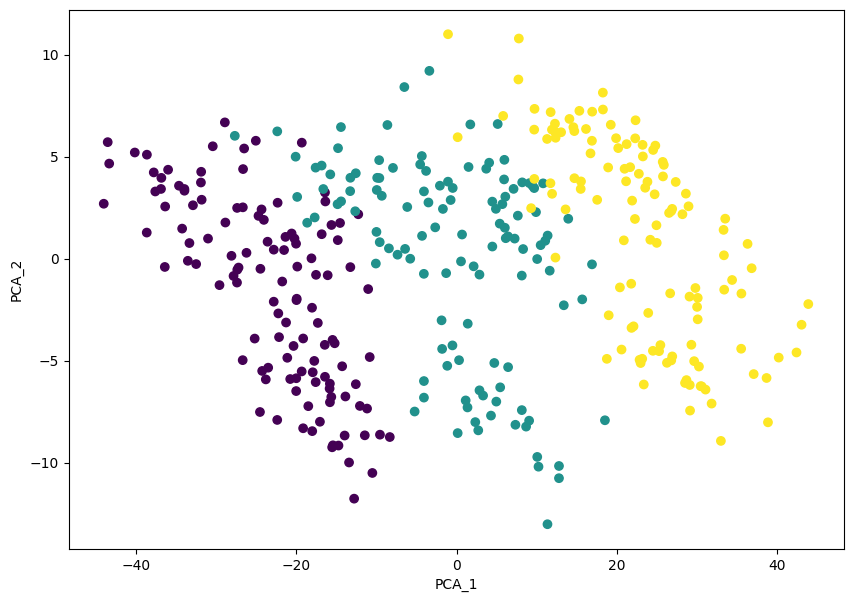

In [116]:
plt.figure(figsize=(10, 7))

known_mask = data['style'].isin([0, 1, 2]).values
plt.scatter(data_pca[known_mask, 0], data_pca[known_mask, 1], c=data.loc[known_mask, 'style'])
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')

plt.show()

In [117]:
from sklearn.mixture import GaussianMixture

model = GaussianMixture(n_components=3)

model.fit(data.loc[known_mask, numeric_features], data.loc[known_mask, 'style'])

GaussianMixture(n_components=3)

In [118]:
y_pred = model.predict(data[numeric_features])
np.bincount(y_pred)

array([1335, 1332, 1333])

In [119]:
subtask1 = ((orig_data['location']=='The Old Library') & (orig_data['tech_assist']==1)).sum().item()
condition2 = ((orig_data['location']=='Crystal Cave') & (orig_data['tech_assist']==1) & ((orig_data['puzzle_type']=='Logic') | (orig_data['puzzle_type']=='Sequence')))
subtask2 = round(orig_data.loc[condition2, 'skill_level'].mean() + orig_data.loc[condition2, 'teamwork_score'].mean(), 2).item()
subtask1, subtask2

(304, 115.24)

In [120]:
subm = pd.DataFrame({
    'subtaskID': [1, 2] + [3] * data.shape[0],
    'datapointID': [1, 1] + data.RoundID.tolist(),
    'answer': [subtask1, subtask2] + y_pred.tolist()
})

subm.to_csv("submision.csv", index=False)

subm.head()

,subtaskID,datapointID,answer
0,1,1,304.00
1,2,1,115.24
2,3,0,0.00
3,3,1,0.00
4,3,2,0.00
